# Chunking: два варианта стратегии

Строим два варианта чанкинга поверх EnterpriseRAG-Bench и сравниваем их между собой.
Опираемся на выводы EDA: длина документов сильно различается по `source_type`
(slack ~3.3K символов в среднем, fireflies ~11.5K, confluence — самые длинные и
самые структурированные — заголовки вида `## Purpose`, `## Scope` и т.д.).

**Вариант 1 — fixed-size chunking с overlap.** Простой бейзлайн: режем по токенам
фиксированным окном с перекрытием, без оглядки на структуру источника.

**Вариант 2 — source-aware / structure-aware chunking.** Сначала пытаемся найти
естественные границы в тексте (markdown-заголовки, подписанные секции, абзацы),
и только если их нет — падаем обратно на fixed-size. Это отдельная итерация
пайплайна для сравнения в финальном отчёте (RQ: помогает ли учёт структуры
источника качеству retrieval).

Оба варианта сохраняются в Parquet с одинаковой схемой, чтобы дальше их можно
было единообразно прогнать через индексацию и evaluation.

In [12]:
#!pip install tiktoken

In [13]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import re
import time
import tiktoken
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

pd.set_option("display.max_colwidth", 120)

ds_d = load_dataset("onyx-dot-app/EnterpriseRAG-Bench", "documents")
df_documents = ds_d["test"].to_pandas()
print(df_documents.shape)
df_documents.head(3)

(511962, 4)


,doc_id,source_type,title,content
0,dsid_e54ef48bae78474684a957cf613d47d5,confluence,Runbook: Deploy / Upgrade / Roll Back perf-canary (Prod),"## Purpose\nThis runbook describes the operational procedures to deploy, upgrade, roll back, and safely disable the ..."
1,dsid_229dd48e9b1d466a81ebaffe3ec84469,confluence,Cross-account GPU burst SLO contract and CI lifecycle,"Summary\n\nOverview:\nThis document defines the operational contract (SLOs, quotas, billing guardrails) and the CI/C..."
2,dsid_aeb0022d62bc43beb6549ba92e5655eb,confluence,Third-Party & Vendor Coordination Playbook for Enterprise Onboarding,"Overview\n\nPurpose:\nThis playbook documents the recommended coordination model, validation checks, and runbook ste..."


## Срез корпуса

Полные ~512K документов эмбеддить на CPU за отведённое время нереально (см.
обсуждение hardware requirements). Берём стратифицированную выборку по
`source_type`, сохраняя те же пропорции источников, что и в оригинале —
это и есть обоснование репрезентативности среза для отчёта.

`SAMPLE_SIZE` — единственный параметр, который стоит крутить под доступное
время: 100K хорошая отправная точка для Core Ultra 7 (22 потока, без CUDA).

In [14]:
SAMPLE_SIZE = 100_000
RANDOM_STATE = 42

frac = SAMPLE_SIZE / len(df_documents)

from sklearn.model_selection import train_test_split

_, df_sample = train_test_split(
    df_documents, 
    test_size=SAMPLE_SIZE/len(df_documents), 
    stratify=df_documents['source_type'],
    random_state=RANDOM_STATE
)
df_sample = df_sample.reset_index(drop=True)


print(f"Взято {len(df_sample)} документов из {len(df_documents)}")
comparison = pd.DataFrame({
    "original_share": df_documents["source_type"].value_counts(normalize=True),
    "sample_share": df_sample["source_type"].value_counts(normalize=True),
})
comparison["diff_pct_points"] = (comparison["sample_share"] - comparison["original_share"]) * 100
comparison.round(4)

Взято 100000 документов из 511962


,original_share,sample_share,diff_pct_points
source_type,,,
slack,0.5579,0.5579,-0.0004
gmail,0.2371,0.2371,0.0003
linear,0.0690,0.0690,0.0004
google_drive,0.0490,0.0490,-0.0003
hubspot,0.0293,0.0293,-0.0002
fireflies,0.0199,0.0199,-0.0001
github,0.0157,0.0157,0.0002
jira,0.0120,0.0120,-0.0004
confluence,0.0101,0.0101,0.0004


Разница долей по источникам должна быть в пределах долей процента — если
где-то поехало сильнее, увеличьте `SAMPLE_SIZE` или проверьте `RANDOM_STATE`.

## Токенизация

Используем `tiktoken` (`cl100k_base`) для подсчёта токенов — быстрый, не требует
загрузки эмбеддинг-модели только ради подсчёта длины. Реальный эмбеддер (e5-small
и т.п.) будет считать чуть иначе, но для выбора размера окна chunking этого
достаточно.

In [15]:
enc = tiktoken.get_encoding("cl100k_base")

def clean_text_for_tokenization(text: str) -> str:
    """Очищает текст от проблемных символов перед токенизацией"""
    if not isinstance(text, str):
        return ""
    # Заменяем или удаляем проблемные символы
    text = text.replace('\x00', '')  # Удаляем null байты
    return text

def n_tokens(text: str) -> int:
    cleaned_text = clean_text_for_tokenization(text)
    return len(enc.encode(cleaned_text, allowed_special=set(), disallowed_special=()))

## Вариант 1 — fixed-size chunking с overlap

Режем каждый документ по токенам окном `chunk_size` с перекрытием `overlap`.
Не учитывает структуру документа вообще — это и есть смысл бейзлайна.

In [18]:
def fixed_chunk(text: str, chunk_size: int = 256, overlap: int = 32):
    # возвращает список (chunk_text, token_start, token_end)
    clean_text = clean_text_for_tokenization(text)
    tokens = enc.encode(clean_text, allowed_special=set(), disallowed_special=())
    if not tokens:
        return []
    chunks = []
    start = 0
    while start < len(tokens):
        end = min(start + chunk_size, len(tokens))
        chunk_tokens = tokens[start:end]
        chunks.append((enc.decode(chunk_tokens), start, end))
        if end == len(tokens):
            break
        start = end - overlap
    return chunks


def chunk_dataframe(df, chunk_fn, strategy_name, **chunk_kwargs):
    rows = []
    for doc_id, source_type, content in zip(df["doc_id"], df["source_type"], df["content"]):
        pieces = chunk_fn(content, **chunk_kwargs)
        for idx, piece in enumerate(pieces):
            text = piece[0] if isinstance(piece, tuple) else piece
            rows.append({
                "chunk_id": f"{doc_id}_{strategy_name}_{idx:03d}",
                "doc_id": doc_id,
                "source_type": source_type,
                "chunk_idx": idx,
                "chunk_text": text,
                "n_tokens": n_tokens(text),
                "strategy": strategy_name,
            })
    return pd.DataFrame(rows)

In [19]:
CHUNK_SIZE = 256
OVERLAP = 32

t0 = time.time()
chunks_v1 = chunk_dataframe(
    df_sample, fixed_chunk, "fixed_v1",
    chunk_size=CHUNK_SIZE, overlap=OVERLAP,
)
t1 = time.time()

print(f"Вариант 1 (fixed): {len(chunks_v1)} чанков из {len(df_sample)} документов")
print(f"Время: {t1 - t0:.1f} сек, {(t1 - t0) / len(df_sample) * 1000:.2f} мс/документ")
chunks_v1.head(3)

Вариант 1 (fixed): 570005 чанков из 100000 документов
Время: 134.9 сек, 1.35 мс/документ


,chunk_id,doc_id,source_type,chunk_idx,chunk_text,n_tokens,strategy
0,dsid_ce88664d7c0e45dfb677c89691a1f5e5_fixed_v1_000,dsid_ce88664d7c0e45dfb677c89691a1f5e5,gmail,0,"[""From: Alyssa Young <alyssa@edgetech.io>\nTo: Mateo Alvarez <mateo_alvarez@redwood.com>\nCc: procure@edgetech.io <p...",256,fixed_v1
1,dsid_ce88664d7c0e45dfb677c89691a1f5e5_fixed_v1_001,dsid_ce88664d7c0e45dfb677c89691a1f5e5,gmail,1,"-off or PO, I can loop procurement. I attached a short POC summary and our billing export showing usage.\n\nAttachme...",256,fixed_v1
2,dsid_ce88664d7c0e45dfb677c89691a1f5e5_fixed_v1_002,dsid_ce88664d7c0e45dfb677c89691a1f5e5,gmail,2,Can you confirm the EdgeTech account ID tied to the export (we saw two accounts under a similar name)?\n- Is the 20...,256,fixed_v1


## Вариант 2 — source-aware / structure-aware chunking

Логика:

1. Пытаемся найти в тексте естественные структурные границы — markdown-заголовки
   (`## Purpose`, `### Scope`) или подписанные секции (`Overview:`, `Acceptance
   criteria:`), характерные для confluence / jira / linear / github.
2. Если заголовков нет, но есть параграфы (двойной перенос строки) — характерно
   для писем (gmail), CRM-заметок (hubspot), транскриптов (fireflies) — режем
   по параграфам.
3. Собранные единицы (секции/параграфы) жадно упаковываем в чанки до
   `chunk_size` токенов, с overlap в одну "единицу" на стыке — так соседний
   чанк не теряет контекст на границе секции.
4. Если ни заголовков, ни параграфов нет (короткие slack-сообщения, часть
   hubspot-записей) или единственная секция всё равно длиннее `chunk_size` —
   откатываемся на `fixed_chunk` из варианта 1.

Так короткие документы (slack, часть hubspot) почти не режутся вообще, а
длинные структурированные (confluence, jira) режутся по смысловым границам,
а не произвольно посреди предложения.

In [20]:
HEADER_RE = re.compile(r'(?m)^(#{1,4}\s.+|[A-Z][A-Za-z /&]{2,40}:)\s*$')


def split_into_units(text: str):
    matches = list(HEADER_RE.finditer(text))
    if len(matches) >= 2:
        units = []
        for i, m in enumerate(matches):
            start = m.start()
            end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
            unit = text[start:end].strip()
            if unit:
                units.append(unit)
        return units

    paras = [p.strip() for p in re.split(r'\n\s*\n', text) if p.strip()]
    if len(paras) >= 2:
        return paras

    return [text]


def pack_units(units, chunk_size: int = 256, overlap_units: int = 1):
    chunks = []
    cur, cur_tokens = [], 0
    for u in units:
        u_tok = n_tokens(u)
        if cur and cur_tokens + u_tok > chunk_size:
            chunks.append("\n\n".join(cur))
            cur = cur[-overlap_units:] if overlap_units else []
            cur_tokens = sum(n_tokens(c) for c in cur)
        cur.append(u)
        cur_tokens += u_tok
    if cur:
        chunks.append("\n\n".join(cur))
    return chunks


def structure_aware_chunk(text: str, chunk_size: int = 256, overlap_units: int = 1, overlap_tokens: int = 32):
    if not text.strip():
        return []
    units = split_into_units(text)
    if len(units) == 1 and n_tokens(units[0]) > chunk_size:
        # нет структуры и текст длинный -> откат на fixed-size
        return [c[0] for c in fixed_chunk(text, chunk_size=chunk_size, overlap=overlap_tokens)]
    return pack_units(units, chunk_size=chunk_size, overlap_units=overlap_units)

In [21]:
t0 = time.time()
chunks_v2 = chunk_dataframe(
    df_sample, structure_aware_chunk, "structure_v2",
    chunk_size=CHUNK_SIZE, overlap_units=1, overlap_tokens=OVERLAP,
)
t1 = time.time()

print(f"Вариант 2 (structure-aware): {len(chunks_v2)} чанков из {len(df_sample)} документов")
print(f"Время: {t1 - t0:.1f} сек, {(t1 - t0) / len(df_sample) * 1000:.2f} мс/документ")
chunks_v2.head(3)

Вариант 2 (structure-aware): 563797 чанков из 100000 документов
Время: 180.8 сек, 1.81 мс/документ


,chunk_id,doc_id,source_type,chunk_idx,chunk_text,n_tokens,strategy
0,dsid_ce88664d7c0e45dfb677c89691a1f5e5_structure_v2_000,dsid_ce88664d7c0e45dfb677c89691a1f5e5,gmail,0,"[""From: Alyssa Young <alyssa@edgetech.io>\nTo: Mateo Alvarez <mateo_alvarez@redwood.com>\nCc: procure@edgetech.io <p...",256,structure_v2
1,dsid_ce88664d7c0e45dfb677c89691a1f5e5_structure_v2_001,dsid_ce88664d7c0e45dfb677c89691a1f5e5,gmail,1,"-off or PO, I can loop procurement. I attached a short POC summary and our billing export showing usage.\n\nAttachme...",256,structure_v2
2,dsid_ce88664d7c0e45dfb677c89691a1f5e5_structure_v2_002,dsid_ce88664d7c0e45dfb677c89691a1f5e5,gmail,2,Can you confirm the EdgeTech account ID tied to the export (we saw two accounts under a similar name)?\n- Is the 20...,256,structure_v2


## Сравнение двух вариантов

Смотрим три вещи, которые пригодятся и для отчёта, и для слайда "experimental
pipeline": (1) сколько чанков получилось всего и на документ, (2) как
распределена длина чанков в токенах, (3) отличается ли поведение по
`source_type` — именно на этом и должна проявиться разница подходов.

In [28]:
summary = pd.DataFrame({
    "total_chunks": [len(chunks_v1), len(chunks_v2)],
    "chunks_per_doc_mean": [
        chunks_v1.groupby("doc_id").size().mean(),
        chunks_v2.groupby("doc_id").size().mean(),
    ],
    "tokens_per_chunk_mean": [chunks_v1["n_tokens"].mean(), chunks_v2["n_tokens"].mean()],
    "tokens_per_chunk_median": [chunks_v1["n_tokens"].median(), chunks_v2["n_tokens"].median()],
    "tokens_per_chunk_std": [chunks_v1["n_tokens"].std(), chunks_v2["n_tokens"].std()],
}, index=["fixed_v1", "structure_v2"])
summary.round(1)

,total_chunks,chunks_per_doc_mean,tokens_per_chunk_mean,tokens_per_chunk_median,tokens_per_chunk_std
fixed_v1,570005,5.7,236.5,256.0,50.2
structure_v2,563797,5.6,263.9,256.0,209.0


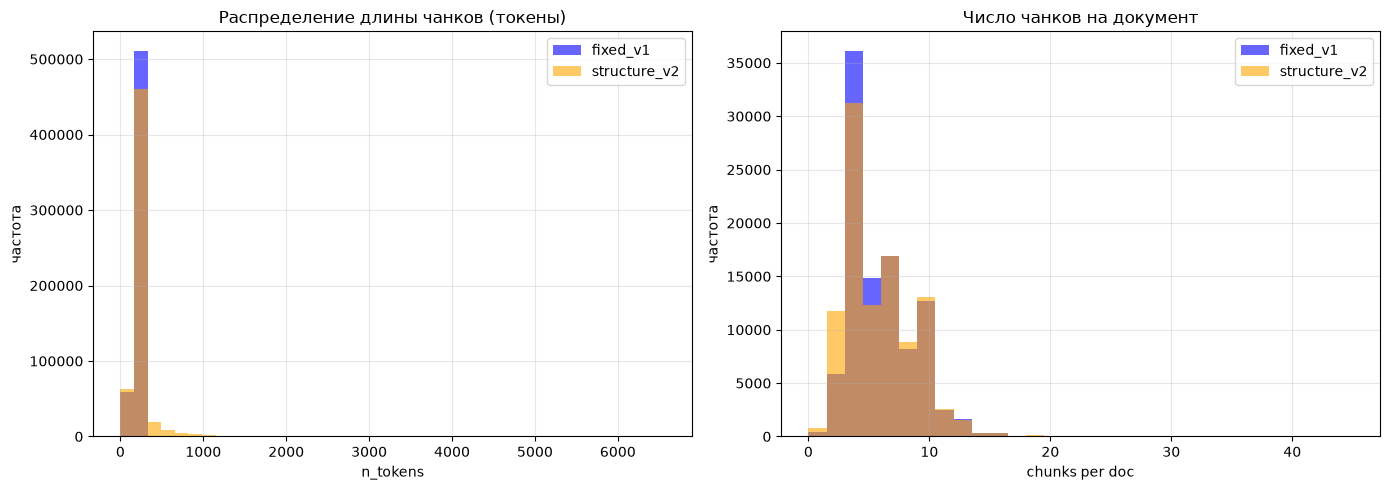

In [34]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Задаём общие границы бинов для первого графика
all_tokens = pd.concat([chunks_v1["n_tokens"], chunks_v2["n_tokens"]])
bins = np.linspace(0, all_tokens.max(), 41)  # 40 бинов от 0 до максимума

axes[0].hist(chunks_v1["n_tokens"], bins=bins, alpha=0.6, label="fixed_v1", color='blue')
axes[0].hist(chunks_v2["n_tokens"], bins=bins, alpha=0.6, label="structure_v2", color='orange')
axes[0].set_title("Распределение длины чанков (токены)")
axes[0].set_xlabel("n_tokens")
axes[0].set_ylabel("частота")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Второй график — также общие бины (можно оставить автоматические, но для единообразия тоже зададим)
per_doc_v1 = chunks_v1.groupby("doc_id").size()
per_doc_v2 = chunks_v2.groupby("doc_id").size()
max_chunks = max(per_doc_v1.max(), per_doc_v2.max())
bins2 = np.linspace(0, max_chunks, 31)  # 30 бинов

axes[1].hist(per_doc_v1, bins=bins2, alpha=0.6, label="fixed_v1", color='blue')
axes[1].hist(per_doc_v2, bins=bins2, alpha=0.6, label="structure_v2", color='orange')
axes[1].set_title("Число чанков на документ")
axes[1].set_xlabel("chunks per doc")
axes[1].set_ylabel("частота")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
by_source = pd.DataFrame({
    "fixed_v1_chunks_per_doc": chunks_v1.groupby(["source_type", "doc_id"]).size().groupby("source_type").mean(),
    "structure_v2_chunks_per_doc": chunks_v2.groupby(["source_type", "doc_id"]).size().groupby("source_type").mean(),
})
by_source["diff"] = by_source["structure_v2_chunks_per_doc"] - by_source["fixed_v1_chunks_per_doc"]
by_source.sort_values("diff").round(2)

,fixed_v1_chunks_per_doc,structure_v2_chunks_per_doc,diff
source_type,,,
fireflies,12.77,5.90,-6.87
google_drive,7.68,7.01,-0.67
jira,5.93,5.50,-0.43
gmail,8.75,8.68,-0.07
github,4.78,4.74,-0.05
slack,4.08,4.19,0.11
hubspot,3.62,3.83,0.20
confluence,10.19,10.86,0.67
linear,5.24,6.06,0.81


Ожидаемая картина: на `confluence` / `jira` / `github` structure-aware даёт
чанки, выровненные по секциям (может быть чуть больше или меньше чанков на
документ в зависимости от того, насколько секции крупнее/мельче фиксированного
окна), а на `slack` разница должна быть минимальной — там документы и так
короче окна, оба варианта почти не режут.

Если распределение выглядит иначе — присмотритесь к `HEADER_RE`: возможно,
для части confluence-документов используется другой формат заголовков, стоит
дописать паттерн под них.

## Сохранение для следующего этапа (индексация)

Схема совпадает с той, что обсуждали для архитектуры хранения: `chunk_id`,
`doc_id`, `source_type`, `chunk_text`, плюс тег стратегии — это то, что дальше
пойдёт в BM25 / Qdrant.

In [25]:
chunks_v1.to_parquet("chunks_fixed_v1.parquet", index=False)
chunks_v2.to_parquet("chunks_structure_v2.parquet", index=False)

print("Сохранено:")
print(f"  chunks_fixed_v1.parquet      — {len(chunks_v1)} строк")
print(f"  chunks_structure_v2.parquet  — {len(chunks_v2)} строк")

Сохранено:
  chunks_fixed_v1.parquet      — 570005 строк
  chunks_structure_v2.parquet  — 563797 строк


## Дальше

Оба parquet-файла независимо прогоняются через одинаковый pipeline индексации
(BM25 + dense + SPLADE), чтобы сравнение на уровне retrieval-метрик (NDCG,
MRR по `questions.jsonl`) было честным — единственная переменная между
итерациями на этом шаге — стратегия чанкинга.